In [1]:
from accessx.aoi import load_aoi, make_hex_grid
from accessx.graph import build_network, save_graph, load_graph
from accessx.cost import add_time_cost_constant_speed
from accessx.cost import add_slope_based_time, add_edge_cost
from accessx.poi import get_pois_osm
from accessx.isochrone import calculate_isochrones
from accessx.accessibility import count_accessible_pois, compute_nearest_poi_cost, compute_hansen_accessibility


from geopandas import read_file
import matplotlib.pyplot as plt

from IPython.display import display



## Define AOI & Create Hexagons

In [2]:
bbox_milano = (
    9.1860,   # minx (lon)
    45.4620,  # miny (lat)
    9.1960,   # maxx (lon)
    45.4680,  # maxy (lat)
)

data_path = 'data/milan'
area_file = data_path + '/area/milano_shapefile/A090101_ComuneMilano.shp'
city_epsg = 32632
buffer=100


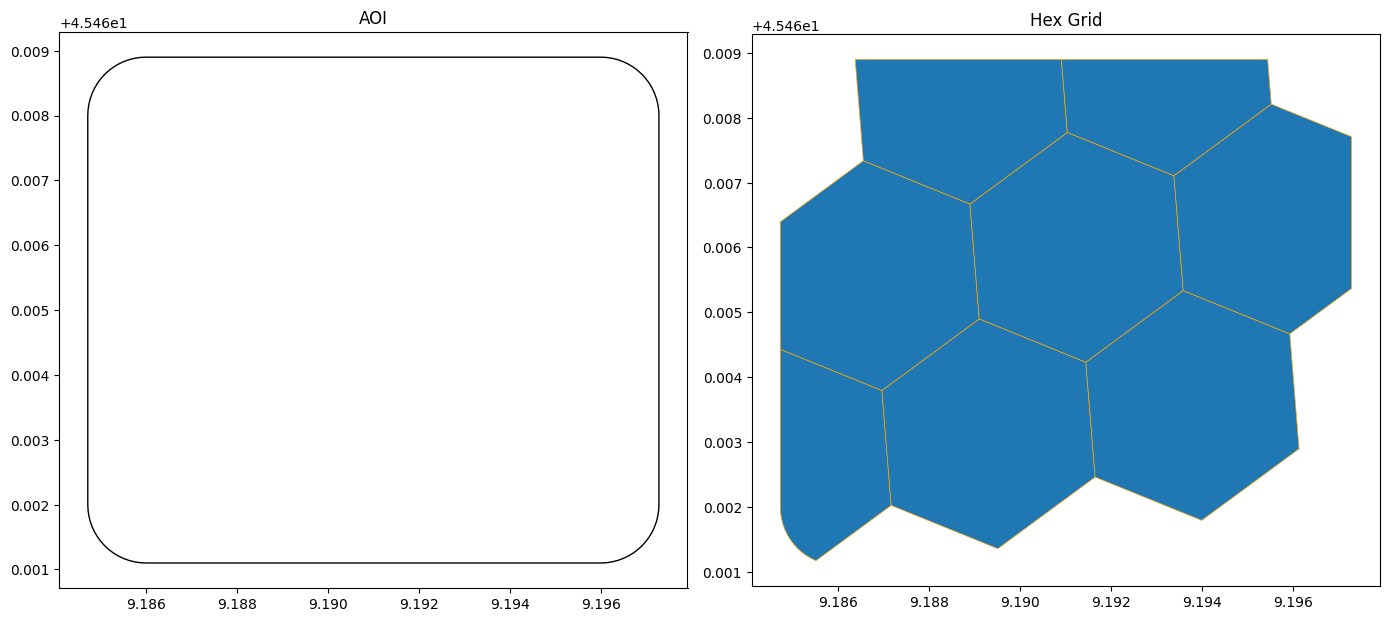

In [6]:
aoi = load_aoi(bbox=bbox_milano, buffer_m=100, utm_crs=city_epsg, save_path=data_path + "area_of_interest.geojson")

# # Municipality of Milano
# aoi = load_aoi(filepath=area_file, buffer_m=0, utm_crs=city_epsg, save_path="data/area/area_of_interest_milan.geojson")

# this calls H3's ppolyfill : “All H3 cell indexes whose centers fall inside the polygon.”
hexes = make_hex_grid(aoi,resolution=9, clip=True)
hexes_proj = hexes.to_crs(city_epsg)
hexes_proj.to_file(data_path + '/area/hexes.geojson', driver="GeoJSON")



fig, axes = plt.subplots(1, 2, figsize=(14, 7))
aoi.plot(ax=axes[0], facecolor="none", edgecolor="black")
axes[0].set_title("AOI")
hexes.plot(ax=axes[1], edgecolor="orange", linewidth=0.5)
axes[1].set_title("Hex Grid")
plt.tight_layout()
plt.show()

## Get street network

In [6]:
buffer=1000

G_proj = build_network(
    AOI=aoi,
    city_epsg=city_epsg,
    buffer_m=buffer,
    network_type="walk",
    simplify=False,
    retain_all=True,
)


save_graph(
    G_proj,
    out_dir= data_path + "/street_network/",
    base_name="original_graph_milan",
    save_nodes=True,
    save_edges=True,
)

## Calculate cost per street segment 

### The cost can be the time to traverse a street based on a defined constant speed...

In [7]:
# time-cost based on costant speed defined by the user
G_proj = add_time_cost_constant_speed(G_proj, speed_kmh=4.5, cost_col="avg_time")


### ...or the time when using speed adjusted to the slope of the streets 
(in %, assuming slope_pct has been added to the graph)...

In [ ]:
# custom cost defined by specific function that receives edge as input and returns cost
# example with function that returns time-cost based on slope-related speeds

# G_proj = add_edge_cost(
#     G_proj,
#     cost_fn=add_slope_based_time(slope_col="slope_pct"),
#     cost_col="slope_based_time",
# )


### ... or your own cost function..

In [ ]:
def discomfort(edge):
    bad = 1.0 if edge.get("lit") == "yes" else 1.5
    return edge["length"] * bad

# G_proj = add_edge_cost(G_proj, cost_fn=discomfort, cost_col="discomfort")

### Save and load graph

In [8]:
save_graph(
    G_proj,
    out_dir= data_path + "/street_network/",
    base_name="graph_with_cost",
    save_nodes=True,
    save_edges=True,
)

## Calculate isochrones

In [9]:
# read street network
G_proj = load_graph(
    nodes_path= data_path + "/street_network/graph_with_cost_nodes_OSM.geojson",
    edges_path= data_path + "/street_network/graph_with_cost_edges_OSM.geojson",
    crs=city_epsg
)

# read hex-grid
hexes_proj = read_file(data_path + '/area/hexes.geojson')


In [ ]:
import os

gdf_hex = calculate_isochrones(
    G_proj,
    hexes_proj,
    max_cost=15,
    interval_size=1,
    cost_attr="avg_time",
    city_epsg=city_epsg,    
    max_distance=200,
    method="edges", # or hull
    n_jobs = os.cpu_count() - 1,
    edge_buff=25,
    infill=True,
    base_name = "walksheds_area_of_interest",
    save_dir='data/walksheds/',
)

/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lamb

### Collect POIs

### Tags Library as an example of how existing categories are groupped and supported. 
Users can define their own according to OpenStreetMap Wiki https://wiki.openstreetmap.org/wiki/Map_features 

In [ ]:
tags_library = {
    # ############# Neighborhood services #############################
    "lily": {
        "amenity": [
            "post_office",
            "bank", "atm",
            "community_centre", "social_facility", "social_centre",
            "police", "fire_station",
            "place_of_worship",
            "drinking_water", "water_point", "watering_place",
            "bar",
            "cafe", "ice_cream",
            "townhall",
        ],
        "shop": ["tobacco", "kiosk", "newsagent"],
        "place": ["square"],
        # optional / future
        "office": ["cleaning", "gardener", "computer"],
    },

    # ############## Healthcare #############################
    "healthcare": {
        "amenity": ["hospital", "pharmacy", "clinic", "dentist", "doctor", "veterinary"],
        "emergency": True,  # any emergency=*
    },

    # ############# Neighbourhood shops #############################
    "neighbourhood_shops": {
        "shop": [
            "grocery", "supermarket", "convenience",
            "greengrocer", "butcher", "dairy", "bakery",
            "general", "variety_store",
            "books",
            "electronics", "clothes", "shoes",
        ],
        "amenity": [
            "vending_machine",
            "toy_library",
            "marketplace",
            "restaurant", "fast_food", "food_court",
        ],
    },

    # ############# Education #############################
    "education": {
        "amenity": [
            "kindergarten", "childcare",
            "school",
            "university", "college", "research_institute",
            "music_school", "language_school", "first_aid_school",
            "training", "driving_school", "dancing_school",
            "library", "public_bookcase",
        ],
    },

    # ############# Sports #############################
    "sports": {
        "leisure": ["fitness_centre", "fitness_station", "sports_centre", "sports_hall"],
        "sport": ["gymnastics", "swimming"],
    },

        "swim": {
        "leisure": ["fitness_centre", "fitness_station", "sports_centre", "sports_hall"],
        "sport": ["gymnastics", "swimming"],
    },


    # ############# Cultural & entertainment #############################
    "cultural": {
        "amenity": ["cinema", "theatre", "arts_centre"],
        "tourism": ["museum"],
    },

    # ############# Open Leisure #############################
    "open_leisure": {
        "leisure": ["park", "playground", "dog_park", "garden"],
        "amenity": ["bbq"],
    },

    # ############# Mobility #############################
    "mobility": {
        "highway": ["bus_stop"],
        "railway": ["tram_stop", "subway_entrance", "station", "halt"],
        "amenity": ["bicycle_parking", "bicycle_rental", "car_sharing", "taxi"],
        # optional (from your old library style)
        "public_transport": ["stop_position"],
    },
}


In [ ]:
tags_library = {
    # ############# Neighborhood services #############################
    "fun": {
        "amenity": [
            "post_office",
            "bank", "atm",
            "community_centre", "social_facility", "social_centre",
            "police", "fire_station",
            "place_of_worship",
            "bar",
            "cafe", "ice_cream",
          
        ],
    "post_office" : {"amenity":["post_office"]},

    "thirst": {
    "amentiy": [  "drinking_water", "water_point", "watering_place",]}


}


### Collecting POIs

In [ ]:
# clean default
pois_default = get_pois_osm(aoi,
                            tags_library=tags_library,  
                            categories=[
                                    "neighborhood_services", 
                                #      "healthcare",
                                    #  "neighbourhood_shops", 
                                    #  "education",
                                    #  "sports",
                                    #  "cultural",
                                    #  "open_leisure",
                                #      "mobility"
                                    ])

# # include a few extras features
# pois_extra = get_pois_osm(aoi, categories=["cultural"], columns=["name", "opening_hours", "wheelchair"])

# # everything
# pois_all = get_pois_osm(aoi, categories=["open_leisure", "mobility"], columns="all")

NameError: name 'aoi' is not defined

In [15]:
pois_default.to_file(data_path + '/pois/pois_default.geojson', driver="GeoJSON")
# pois_extra.to_file('data/pois/pois_extra.geojson', driver="GeoJSON")
# pois_all.to_file('data/pois/pois_all.geojson', driver="GeoJSON")


NameError: name 'pois_default' is not defined

## Accessibility Estimation

### Reading the data neeed - Graph, Hexes, Pois

In [10]:
# read street network
G_proj = load_graph(
    nodes_path=data_path + "/street_network/graph_with_cost_nodes_OSM.geojson",
    edges_path=data_path + "/street_network/graph_with_cost_edges_OSM.geojson",
    crs=32632
)

# read hex-grid
hexes_proj = read_file(data_path + '/area/hexes.geojson')

pois_default = read_file(data_path + '/pois/pois_default.geojson')


### Cumulative Opportunities Accessibility (per category)

For a given origin location *i* and destination category *k* (e.g. pharmacy, playground),
accessibility is defined as the number of destinations of that category reachable within
a travel-cost threshold $\tau$:

$$
A_{i,k}(\tau) = \sum_{p \in \mathcal{P}_k} \mathbb{1}\!\left(c_{ip} \le \tau \right)
$$

where:

- $A_{i,k}(\tau)$ is the cumulative accessibility of category $k$ at origin $i$
- $\mathcal{P}_k$ is the set of POIs belonging to category $k$
- $c_{ip}$ is the travel cost from $i$ to POI $p$
- $\tau$ is the travel-cost threshold (e.g. 5, 10, 15 minutes)
- $\mathbb{1}(\cdot)$ is an indicator function equal to 1 if the condition is met, 0 otherwise


In [13]:
gdf_access_count = count_accessible_pois(G_proj, 
                                         hexes_proj, 
                                         pois_default, 
                                         max_cost=5, 
                                         cost_attr="avg_time",
                                        max_distance_from_graph=200)
gdf_access_count.head(10)


,hex_id,geometry,count_healthcare,count_mobility,count_neighborhood_services
0,891f99cdd4bffff,"POLYGON ((514615.567 5034491.191, 514631.974 5...",8,36,59
1,891f99cdd4fffff,"POLYGON ((514615.567 5034491.191, 514782.596 5...",14,74,78
2,891f99cdd7bffff,"POLYGON ((514982.445 5034343.737, 514966.035 5...",8,35,45
3,891f99cdd43ffff,"POLYGON ((514582.755 5034884.748, 514766.188 5...",15,71,81
4,891f99cdd47ffff,"POLYGON ((514766.188 5034811.027, 514933.215 5...",6,48,78
5,891f99cdd73ffff,"POLYGON ((515316.51 5034589.854, 515133.066 50...",0,0,0
6,891f99cdd57ffff,"POLYGON ((514933.215 5034934.082, 514766.188 5...",2,13,43
7,891f99cdd0bffff,"POLYGON ((515283.683 5034983.417, 515116.654 5...",1,14,18


### Nearest-POI Accessibility (per category)

For a given origin location *i* and destination category *k*,
accessibility is defined as the minimum travel cost required to reach
the nearest destination of that category:

$$
C_{i,k} = \min_{p \in \mathcal{P}_k} \; c_{ip}
$$

where:

- $C_{i,k}$ is the minimum travel cost from origin $i$ to the nearest POI of category $k$
- $\mathcal{P}_k$ is the set of POIs belonging to category $k$
- $c_{ip}$ is the travel cost from $i$ to POI $p$ (e.g. walking time)


In [4]:
gdf_access_nearest_long = compute_nearest_poi_cost(G_proj, 
                                              hexes_proj, 
                                              pois_default, 
                                              max_cost=5, 
                                              poi_id_col='osmid', 
                                              cost_attr="avg_time", 
                                              output='long',
                                              max_distance_from_graph=200)

gdf_access_nearest_wide = compute_nearest_poi_cost(G_proj, 
                                              hexes_proj, 
                                              pois_default, 
                                              max_cost=5, 
                                              poi_id_col='osmid', 
                                              cost_attr="avg_time", 
                                              output='wide',
                                              max_distance_from_graph=200)

gdf_access_nearest_list = compute_nearest_poi_cost(G_proj, 
                                              hexes_proj, 
                                              pois_default, 
                                              max_cost=5, 
                                              poi_id_col='osmid', 
                                              cost_attr="avg_time", 
                                              output='list',
                                              max_distance_from_graph=200)

print("LONG")
display(gdf_access_nearest_long.head())
print("\nWIDE")

display(gdf_access_nearest_wide.head())
print("\nLIST")

display(gdf_access_nearest_list.head())

LONG


,hex_id,category,rank,cost,osmid
0,891f99cdd4bffff,healthcare,1,1.309854,1678582986
1,891f99cdd4bffff,mobility,1,1.743259,316535136
2,891f99cdd4bffff,neighborhood_services,1,0.834480,5033959344
3,891f99cdd4fffff,healthcare,1,1.541549,661556413
4,891f99cdd4fffff,mobility,1,0.610917,316535192



WIDE


,hex_id,geometry,nearest_cost_healthcare_1,nearest_poi_healthcare_1,nearest_cost_mobility_1,nearest_poi_mobility_1,nearest_cost_neighborhood_services_1,nearest_poi_neighborhood_services_1
0,891f99cdd4bffff,"POLYGON ((514615.567 5034491.191, 514631.974 5...",1.309854,1.678583e+09,1.743259,3.165351e+08,0.834480,5.033959e+09
1,891f99cdd4fffff,"POLYGON ((514615.567 5034491.191, 514782.596 5...",1.541549,6.615564e+08,0.610917,3.165352e+08,0.342581,7.660261e+09
2,891f99cdd7bffff,"POLYGON ((514982.445 5034343.737, 514966.035 5...",1.686605,3.030453e+09,1.912938,1.479193e+09,0.857198,2.759534e+07
3,891f99cdd43ffff,"POLYGON ((514582.755 5034884.748, 514766.188 5...",0.161822,9.006254e+09,0.121787,9.110460e+09,0.179405,2.986744e+08
4,891f99cdd47ffff,"POLYGON ((514766.188 5034811.027, 514933.215 5...",2.464096,1.029555e+10,0.835718,5.350658e+09,0.000000,5.172906e+09



LIST


,hex_id,geometry,nearest_pois_healthcare,nearest_pois_mobility,nearest_pois_neighborhood_services
0,891f99cdd4bffff,"POLYGON ((514615.567 5034491.191, 514631.974 5...","[(1.3098541977718519, 1678582986)]","[(1.7432590718881968, 316535136)]","[(0.8344803961254721, 5033959344)]"
1,891f99cdd4fffff,"POLYGON ((514615.567 5034491.191, 514782.596 5...","[(1.5415492363761554, 661556413)]","[(0.6109170279752663, 316535192)]","[(0.342580645355628, 7660261292)]"
2,891f99cdd7bffff,"POLYGON ((514982.445 5034343.737, 514966.035 5...","[(1.6866046060160054, 3030452589)]","[(1.9129381715064793, 1479193476)]","[(0.85719788483045, 27595336)]"
3,891f99cdd43ffff,"POLYGON ((514582.755 5034884.748, 514766.188 5...","[(0.16182223652186303, 9006254076)]","[(0.12178714497437508, 9110459641)]","[(0.1794049382767503, 298674402)]"
4,891f99cdd47ffff,"POLYGON ((514766.188 5034811.027, 514933.215 5...","[(2.4640959809898324, 10295549849)]","[(0.8357177365324934, 5350658280)]","[(0, 5172906322)]"


In [6]:
gdf_access_nearest_9 = compute_nearest_poi_cost(G_proj, 
                                                hexes_proj, 
                                                pois_default, 
                                                max_cost=5,
                                                number_of_nearest=9, 
                                                poi_id_col='osmid', 
                                                cost_attr="avg_time", 
                                                output="long", #, "long", "wide"
                                                max_distance_from_graph=200)
gdf_access_nearest_9.head(50)

,hex_id,category,rank,cost,osmid
0,891f99cdd4bffff,healthcare,1,1.309854,1678582986
1,891f99cdd4bffff,healthcare,2,3.233513,3007424410
2,891f99cdd4bffff,healthcare,3,3.297380,1678583006
3,891f99cdd4bffff,healthcare,4,3.591582,661556413
4,891f99cdd4bffff,healthcare,5,3.774924,3007424409
5,891f99cdd4bffff,healthcare,6,3.985391,13504506354
6,891f99cdd4bffff,healthcare,7,4.045116,9742918198
7,891f99cdd4bffff,healthcare,8,4.924867,13371864752
8,891f99cdd4bffff,mobility,1,1.743259,316535136
9,891f99cdd4bffff,mobility,2,2.404100,4898290186


### Weighted Hansen Accessibility (per POI and per category)

Let location *i* be an origin (e.g., a hex cell). Let destinations be individual POIs indexed by *p*.
Each POI belongs to a category *k(p)* (e.g., pharmacy, playground, metro).

We define accessibility at *i* as:

$$
A_i = \sum_{p \in \mathcal{P}} \Big( w_{k(p)} \cdot w_p \cdot O_p \Big)\; f(c_{ip})
$$

where:

- $A_i$ is the accessibility score at origin $i$
- $\mathcal{P}$ is the set of all POIs
- $O_p$ is the opportunity magnitude of POI $p$ (often $O_p=1$ if each POI counts equally)
- $w_{k(p)}$ is the weight of POI category $k$ (e.g., pharmacies might count more than playgrounds)
- $w_p$ is an optional POI-specific weight (e.g., capacity/size/importance of that specific POI)
- $c_{ip}$ is the travel cost (time, distance, generalized cost) from $i$ to $p$
- $f(c)$ is an impedance (decay) function decreasing with cost

Impedance:

$$
f(c)=e^{-\beta c}

$$



---

#### A small note on the decay function

##### How decay changes accessibility weights (1–30 minute trips)

The following diagram shows the exponential decay function:

$$
f(c)=e^{-\beta c}
$$

for travel times from **1 to 30 minutes**, using three different values of **b** (0.15, 0.30, 0.50).

What’s happening here?

The decay function assigns a **weight** to each destination depending on how far away it is in time.  
Closer places get higher weights. Farther places get lower weights. Simple idea — but the speed of that drop depends entirely on **b**.

The decay basically encodes an assumption about how people experience travel time.


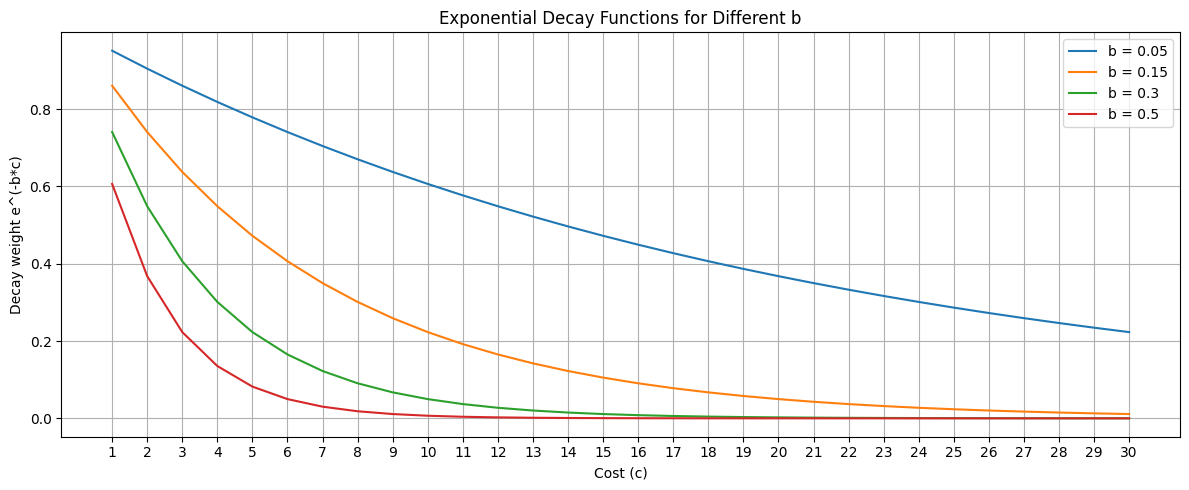

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cost values
c = np.arange(1, 31)

# Decay parameters
b_values = [0.05, 0.15, 0.3, 0.5]

# Make figure wider
plt.figure(figsize=(12, 5))  # width, height in inches

for b in b_values:
    y = np.exp(-b * c)
    plt.plot(c, y, label=f"b = {b}")

plt.xlabel("Cost (c)")
plt.ylabel("Decay weight e^(-b*c)")
plt.title("Exponential Decay Functions for Different b")
plt.legend()

plt.xticks(np.arange(1, 31, 1))
plt.grid(True)

plt.tight_layout()
plt.show()


import numpy as np

def piecewise_exp_decay(c, T=15, b1=0.12, b2=0.45):
    c = np.asarray(c)
    w = np.empty_like(c, dtype=float)

    mask = c <= T
    w[mask] = np.exp(-b1 * c[mask])
    w[~mask] = np.exp(-b1 * T) * np.exp(-b2 * (c[~mask] - T))  # continuous at T
    return w

In [ ]:
gdf_hansen = compute_hansen_accessibility(
    graph=G_proj,
    hexes=hexes,
    pois=pois_default,
    max_cost=5,
    cost_attr="avg_time",
    id_col="hex_id",
    category_col="category",
    # poi_weight_col="capacity",  # per-POI weight column
    # category_weights={          # per-category multipliers
    #     "neighborhood_services": 1.5,
    #     "mobility": 1.2,
    #     "shop": 1.0,
    # },
    default_poi_weight=1.0,
    beta=0.15,
    max_distance_from_graph=200.0,
)

In [54]:
print(pois_default.crs)
print(hexes.crs)
G_proj.graph['crs']

EPSG:4326
EPSG:4326


<Projected CRS: EPSG:32632>
Name: WGS 84 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°E and 12°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Austria. Cameroon. Denmark. Equatorial Guinea. France. Gabon. Germany. Italy. Libya. Liechtenstein. Monaco. Netherlands. Niger. Nigeria. Norway. Sao Tome and Principe. Svalbard. Sweden. Switzerland. Tunisia. Vatican City State.
- bounds: (6.0, 0.0, 12.0, 84.0)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
gdf_hansen.to_file('data/accessibility/hansen.geojson', driver="GeoJSON")
gdf_access_count.to_file('data/accessibility/count.geojson', driver="GeoJSON")
gdf_access_nearest_9.to_file('data/accessibility/nearest9.geojson', driver="GeoJSON")

## 2SFCA Accessibility Model (Catchment-Based)

 **Two-Step Floating Catchment Area (2SFCA)** method to estimate accessibility for each hexagon.

### Intuition
2SFCA combines:
- **Supply** at POIs (e.g., service capacity)
- **Demand** at residential hexagons (e.g., population)
- **Travel cost** on the street network (e.g., walking minutes)

The model returns:
- `sfca_<category>`: accessibility by POI type
- `sfca_total`: combined accessibility across POI categories

### Step 1: Provider-to-Population Ratio
For each POI location \( j \), compute a service ratio:

\[
R_j = \frac{S_j}{\sum_k D_k \cdot f(c_{kj})}
\]

Where:
- \( S_j \): POI supply (capacity or default value)
- \( D_k \): demand at hex \( k \)
- \( c_{kj} \): network travel cost from hex \( k \) to POI \( j \)
- \( f(c) \): distance decay inside the catchment

### Step 2: Accessibility at Each Hex
For each hex \( i \), sum nearby provider ratios:

\[
A_i = \sum_j R_j \cdot f(c_{ij})
\]

Where:
- \( c_{ij} \): network travel cost from hex \( i \) to POI \( j \)

### Decay Options
- `decay="binary"` (classic 2SFCA):  
  \( f(c)=1 \) if \( c \le \text{max_cost} \), otherwise \( 0 \)
- `decay="exp"` (distance-decay variant):  
  \( f(c)=e^{-\beta c} \)

### Inputs Used
- `hexes`: must include geometry, hex id, and `demand_col` (e.g. population)
- `pois`: must include geometry and `category_col`; optional `supply_col`
- `graph`: projected street network with edge cost attribute `cost_attr`
- `max_cost`: catchment threshold (in same units as `cost_attr`)

### Notes
- Hexes/POIs are snapped to nearest graph nodes.
- Hexes farther than `max_distance_from_graph` are skipped.
- Optional `category_weights` can up/down-weight specific POI categories.


In [12]:
from accessx.accessibility import compute_2sfca_accessibility

# Classic 2SFCA (binary catchment)
sfca_binary = compute_2sfca_accessibility(
    graph=G,
    hexes=hexes,                 # needs: hex_id, population, geometry
    pois=pois_default,                   # needs: category, (optional capacity), geometry
    max_cost=15,                 # e.g. minutes
    cost_attr="avg_time",
    demand_col="population",
    id_col="hex_id",
    category_col="category",
    supply_col="capacity",       # optional; if None uses default_supply
    default_supply=1.0,
    category_weights={           # optional
        "pharmacy": 1.0,
        "school": 1.5,
    },
    max_distance_from_graph=200.0,
    decay="binary",              # classic 2SFCA
)

# Distance-decay version (E2SFCA-like)
sfca_exp = compute_2sfca_accessibility(
    graph=G,
    hexes=hexes,
    pois=pois_default,
    max_cost=20,
    cost_attr="avg_time",
    demand_col="population",
    category_col="category",
    supply_col="capacity",
    decay="exp",                 # uses exp(-beta * cost)
    beta=0.15,
)

NameError: name 'G' is not defined

### Equity Analysis

{'count_healthcare': 0.43981481481481477, 'count_mobility': 0.39132302405498276, 'count_neighborhood_services': 0.30659203980099503}


(<Figure size 800x266 with 1 Axes>,
 <Axes: title={'center': 'Athens - Gini Indices'}>,
                         metric      gini
 0             count_healthcare  0.439815
 1               count_mobility  0.391323
 2  count_neighborhood_services  0.306592)

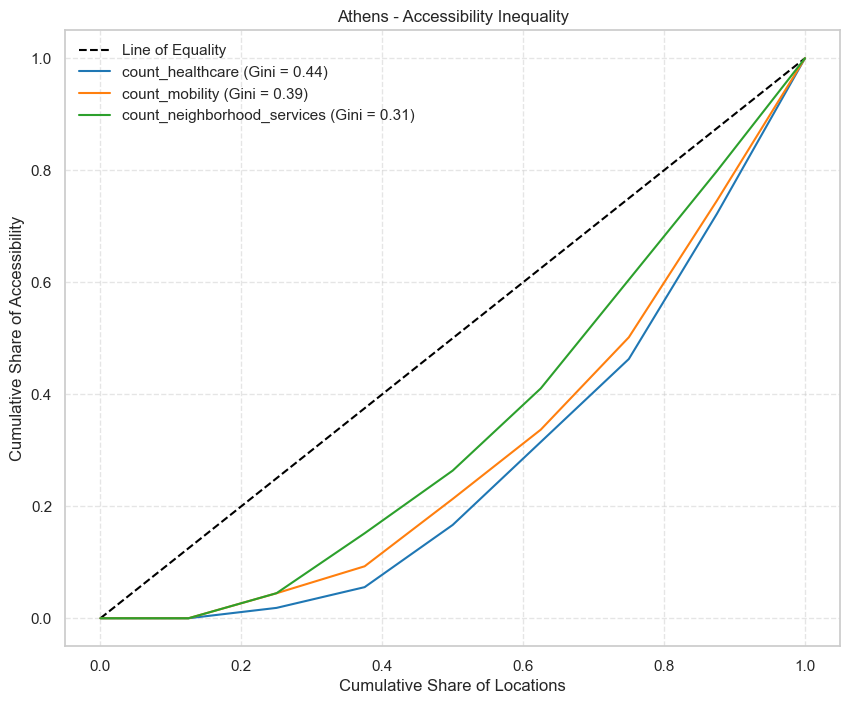

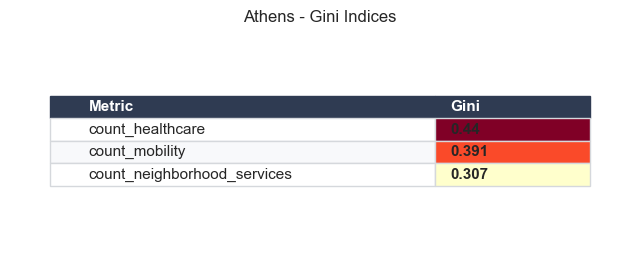

In [ ]:
from accessx.equity import calculate_lorenz, plot_lorenz_curves, plot_gini_table

properties = [
    "count_healthcare",
    "count_mobility",
    "count_neighborhood_services",
]


# 1) Compute Lorenz arrays + Gini
A, P, gini, sorted_vals = calculate_lorenz(
    properties=properties,
    df=gdf_access_count,
)

print(gini)

# 2) Plot Lorenz curves
fig1, ax1, gini1 = plot_lorenz_curves(
    df=gdf_access_count,
    properties=properties,
    title="Athens - Accessibility Inequality",
    show_gini_in_legend=True,
    save_path="lorenz_accessibility.png",  # optional
)

# 3) Plot Gini table (from df + properties)
fig2, ax2, gini_df = plot_gini_table(
    df=gdf_access_count,
    properties=properties,
    title="Athens - Gini Indices",
    sort_desc=True,
    save_path="gini_table.png",  # optional
)


In [ ]:
A, P, gini, _ = calculate_lorenz(properties=["hansen_total"], df=df_access)
fig, ax, _ = plot_lorenz_curves(df=df_access, properties=["hansen_total"])

,hex_id,geometry,count_healthcare,count_mobility,count_neighborhood_services
0,891f99cdd4bffff,"POLYGON ((514615.567 5034491.191, 514631.974 5...",8,36,59
1,891f99cdd4fffff,"POLYGON ((514615.567 5034491.191, 514782.596 5...",14,74,78
2,891f99cdd7bffff,"POLYGON ((514982.445 5034343.737, 514966.035 5...",8,35,45
3,891f99cdd43ffff,"POLYGON ((514582.755 5034884.748, 514766.188 5...",15,71,81
4,891f99cdd47ffff,"POLYGON ((514766.188 5034811.027, 514933.215 5...",6,48,78
5,891f99cdd73ffff,"POLYGON ((515316.51 5034589.854, 515133.066 50...",0,0,0
6,891f99cdd57ffff,"POLYGON ((514933.215 5034934.082, 514766.188 5...",2,13,43
7,891f99cdd0bffff,"POLYGON ((515283.683 5034983.417, 515116.654 5...",1,14,18


2.4.1
/Users/vmlias/repos/accessX/env_accessx/lib/python3.12/site-packages/numpy/__init__.py
False True
